# Домашнее задание №5: Полносвязные нейронные сети

В этом задании вам предстоит пронаблюдать, насколько хорошо нейросети приближают заданные функции на практике, ответить на некоторые теоретические вопросы и попрактиковаться в обучении полносвязных нейронных сетей для классификации изображений.

На практике изображения классифицируют с помощью сверточных нейросетей, но т.к. в базовом курсе ML вы знакомитесь только с полносвязными сетями, а со сверточными в курсе DL, в задании мы также ограничимся полносвязной сетью.

Также заметим, что определенная практическая польза в обучении полносвязной сети для классификации изображений все-таки есть, т.к. в машинном обучении оцень важно в любой задаче иметь бейзлайн - простую модель, с которой будут сравниваться более сложные модели. **Только хороший бейзлайн позволяет понять, насколько ценно более сложное решение.**

## Структура задания
Задание состоит из 4 частей:
1. **Приближение заданной функции**: практическая проверка того, как нейросети могут приближать заданную функцию.
1. **Теоретические вопросы**: проверка понимания базовых принципов работы нейросетей, включая forward и backward pass в полносвязной сети.
1. **Построение нейросети на MNIST**: практическое задание по классификации рукописных цифр.
1. **Построение нейросети на CIFAR10**: более сложная задача классификации изображений.

## Система оценивания домашнего задания

Максимально можно получить 22 балла. Полученные баллы пересчитываются в десятибалльную оценку по формуле:

количество_баллов * 10 / максимум_баллов

**Дробные значения округляются вверх.**


**Пример:**

Если вы набрали 12 баллов из 22, то:

10 * (12/22) = 5,45(45) => после округления вверх оценка 6 баллов из 10

## Библиотека Keras
[Keras](https://keras.io/) — это высокоуровневый API для создания и обучения нейронных сетей. Он разработан для быстрой реализации идей и экспериментов. В этом задании мы будем использовать Keras как простой и интуитивно понятный инструмент для построения ваших первых нейросетей.

## Часть 1: Приближение заданной функции нейросетью

Универсальная теорема аппроксимации это утверждение, которое изначально сильно вдохновило исследователей на активное развитие нейросетей. В машинном обучении обычно мы ищем оптимальную модель в некотором семействе моделей (линейные модели, деревья, бустинги над деревьями). Чем лучше семейство моделей может приблизить реальзую зависимость целевой переменной от признаков объекта, чем более точную модель мы можем построить при достаточном количестве обучающих данных. Оказывается, что даже нейросеть всего лишь с одним скрытым слоем, может приблизить зависимость целевой переменной от признаков с очень высокой точностью.

Универсальная теорема аппроксимации утверждает, что искусственная нейронная сеть прямого распространения с одним скрытым слоем, содержащим конечное число нейронов, может аппроксимировать любую непрерывную функцию на компактных подмножествах $\mathbb{R}^n$, при условии использования подходящей функции активации и подходящего количества нейронов в скрытом слое.

В этой части мы не возьмемся за проверку самой теоремы, но как минимум посмотрим, насколько хорошо нейросеть справляется с приближением заданной вручную функции.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

np.random.seed(42)
plt.style.use('ggplot')

### Пример 1: Восстановление зависимости в области с известными значениями

Рассмотрим для примера функцию $f(x) = \sin(x) + 0.1 \cdot x^2$.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


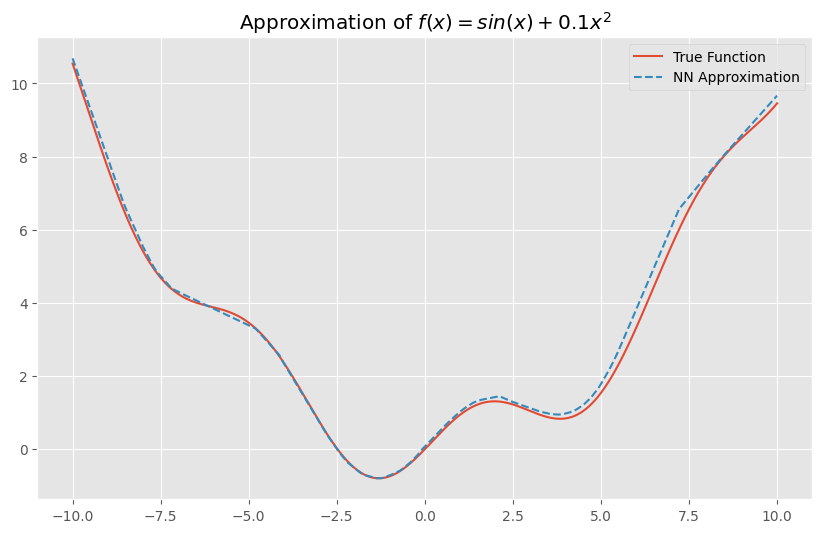

In [5]:
def target_func1(x):
    return np.sin(x) + 0.1 * x**2

# Генерируем данные
X_train1 = np.linspace(-10, 10, 1000).reshape(-1, 1)
y_train1 = target_func1(X_train1)

# Строим модель
model1 = Sequential([
    # ToDo: добавьте Dense слой с активацией relu и input_shape=(1,)
    Dense(units=len(X_train1), activation='relu', input_shape=(1,)),
    Dense(units=50, activation='relu'),
    # ToDo: добавьте выходной слой размера 1 без нелинейности
    Dense(units=1, activation=None)
])

model1.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Обучаем модель
history1 = model1.fit(X_train1, y_train1, epochs=100, batch_size=32, verbose=0)

# Предсказания
y_pred1 = model1.predict(X_train1)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(X_train1, y_train1, label='True Function')
plt.plot(X_train1, y_pred1, label='NN Approximation', linestyle='--')
plt.title('Approximation of $f(x) = sin(x) + 0.1 x^2$')
plt.legend()
plt.show()

### Пример 2: Экстраполяция

Теперь посмотрим, как модель ведет себя вне диапазона обучающих данных.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


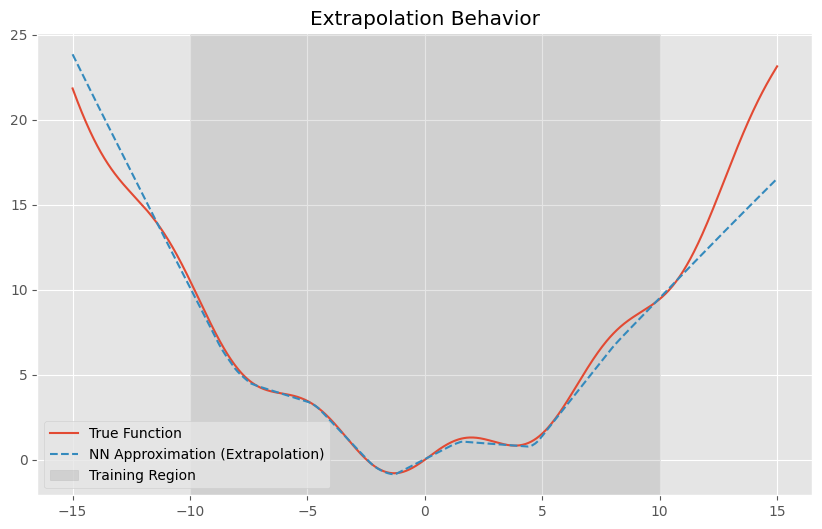

In [4]:
# Данные для экстраполяции
X_test1 = np.linspace(-15, 15, 1000).reshape(-1, 1)

## ToDo: посчитать target_func1 на X_test1 и прогнозы нейросети на X_test1
y_test1_true = target_func1(X_test1)
y_test1_pred = model1.predict(X_test1)

plt.figure(figsize=(10, 6))
plt.plot(X_test1, y_test1_true, label='True Function')
plt.plot(X_test1, y_test1_pred, label='NN Approximation (Extrapolation)', linestyle='--')
plt.axvspan(-10, 10, color='gray', alpha=0.2, label='Training Region')
plt.title('Extrapolation Behavior')
plt.legend()
plt.show()

### Вопросы по Части 1

**Вопрос 1 (1 балл):** Как нейросеть (МЛП с ReLU) справилась с аппроксимацией функции на обучающем отрезке $[-10, 10]$ в Примере 1?
- A) Идеально повторила функцию, ошибка равна в точности нулю.
- B) Неплохо уловила общую форму и локальные колебания (синус).
- C) Выдала одну прямую линию, так как использовалась ReLU.
- D) Не смогла выучить функцию вообще.

*Ответ: B*

**Вопрос 2 (1 балл):** Что происходит с прогнозом, если добавить еще один полносвязный слой из 50 нейронов?
- A) Нейросеть начала приближать зависимость идеально.
- B) Нейросеть приблизила зависимость чуть точнее.
- C) Нейросеть перестала обучаться и стала прогнозировать хуже.
- D) Ничего не изменилось.

*Ответ: B*

**Вопрос 3 (1 балл):** Как нейросеть повела себя за пределами обучающего отрезка (экстраполяция в Примере 2)?
- A) Продолжила точно предсказывать функцию $f(x) = \sin(x) + 0.1 x^2$.
- B) Начала выдавать случайный шум.
- C) Продолжила тренд линейно (кусочно-линейно), так как использует активации ReLU, и перестала улавливать синусоиду.
- D) Предсказания занулились.

*Ответ: C*


**Вопрос 4 (1 балл):** Почему во втором примере (экстраполяция) качество предсказаний резко падает?
- A) Потому что мы использовали Adam, а не SGD.
- B) Потому что размер батча был слишком маленьким.
- C) Потому что нейросети (особенно МЛП) склонны переобучаться на распределение тренировочных данных и плохо обобщают (экстраполируют) паттерны за пределы этого распределения, скатываясь к свойствам своих функций активации (например, линейности на краях для ReLU).
- D) Из-за взрыва градиентов.

*Ответ: С*

## Часть 2: Теоретические вопросы

В этой части вам предлагается ответить на несколько теоретических вопросов, чтобы закрепить понимание того, как работают полносвязные нейронные сети.

**Вопрос 5 (1 балл):** Какова основная роль нелинейной функции активации в скрытых слоях нейросети?
- A) Предотвратить переобучение (как регуляризация).
- B) Ускорить вычисление градиентов.
- C) Позволить сети моделировать нелинейные зависимости (без нее композиция полносвязных слоев сводится к одной линейной трансформации).
- D) Сделать выходы сети вероятностями.

*Ответ: С*

**Вопрос 6 (1 балл):** Как выглядит forward pass для одного полносвязного слоя без функции активации для входа $x$ (вектор-столбца из $D$ координат, $D$ - размерность признаков), матрицы весов $W$ и вектора смещений $b$?
- A) $Z = W \cdot x + b$
- B) $Z = x \cdot W + b$
- C) $Z = x^t \cdot W^T + b$
- D) $Z = W \cdot x^T + b^T$

*Ответ: A*

**Вопрос 7 (1 балл):** Как выглядит forward pass для одного полносвязного слоя без функции активации для входа $X$ (размерности $N \times D$, где $N$ - размер батча, $D$ - размерность признаков), матрицы весов $W$ и вектора смещений $b$?
- A) $Z = W \cdot X + b$
- B) $Z = X \cdot W + b$
- C) $Z = X \cdot W^T $
- D) $Z = W \cdot X^T + b^T$

*Ответ: B*

**Вопрос 8 (2 балла):** Как в матричном виде выглядит производная функции активации ReLU ($f(Z) = \max(0, Z)$) по ее входу $Z$ во время backward pass, если на нее пришел градиент $\frac{\partial L}{\partial A}$ (где $A = \max(0, Z)$)?
- A) $\frac{\partial L}{\partial Z} = \frac{\partial L}{\partial A} \odot Z$
- B) $\frac{\partial L}{\partial Z} = \frac{\partial L}{\partial A} \odot \mathbb{I}(Z > 0)$ (где $\odot$ - поэлементное умножение, а $\mathbb{I}$ - индикаторная функция)
- C) $\frac{\partial L}{\partial Z} = \frac{\partial L}{\partial A} \cdot \mathbb{I}(Z > 0)$
- D) $\frac{\partial L}{\partial Z} = \max(0, \frac{\partial L}{\partial A})$

*Ответ: B*


**Вопрос 9 (2 балла):** Пусть $W$ и $b$ - веса и вектор сдвигов полносвязного слоя. Пусть $\frac{\partial L}{\partial Z}$ - градиент функции потерь $L$ по выходу этого слоя $Z$. Как вычисляется градиент $\frac{\partial L}{\partial W}$ во время backward pass (обратного распространения ошибки), если $X$ - матрица признаков батча (размерности $N \times D$, где $N$ - размер батча, $D$ - размерность признаков)?
- A) $\frac{\partial L}{\partial W} = X + \frac{\partial L}{\partial Z}$
- B) $\frac{\partial L}{\partial W} = X^T \cdot \frac{\partial L}{\partial Z}$
- C) $\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Z} \cdot X^T$
- D) $\frac{\partial L}{\partial W} = W^T \cdot \frac{\partial L}{\partial Z}$

*Ответ: B*

## Часть 3: Построение нейросети на MNIST

В этой части мы поработаем с классическим датасетом рукописных цифр MNIST. Допишите в код ниже архитектуру сети и выполните обучение и оценку качества.

В качестве отправной точки предлагается взять 3 слоя: Dense на 512 нейронов с активацией relu (не ошибитесь с параметром input_shape), Dense на 256 нейронов с активацией relu и Dense на 10 нейронов с активацией softmax.

In [14]:
from keras.datasets import mnist
from keras.utils import to_categorical

# Загрузка данных
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# Предобработка: вытягиваем картинки 28x28 в векторы 784 и нормализуем
X_train_mnist = X_train_mnist.reshape(-1, 28 * 28).astype('float32') / 255.0
X_test_mnist = X_test_mnist.reshape(-1, 28 * 28).astype('float32') / 255.0

# One-hot encoding меток
y_train_mnist_cat = to_categorical(y_train_mnist, 10)
y_test_mnist_cat = to_categorical(y_test_mnist, 10)

# Построение модели
model_mnist = Sequential([
    ## ToDo: дописать слои нейросети
    Dense(units=512, activation='relu', input_shape = [784]),
    Dense(units=256, activation='relu'),
    Dense(units=10, activation='softmax'),
])

model_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Обучение
print("Training MNIST model...")
history_mnist = model_mnist.fit(X_train_mnist, y_train_mnist_cat, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

# Оценка
loss_mnist, acc_mnist = model_mnist.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)
print(f"\nMNIST Test Accuracy: {acc_mnist:.4f}")

Training MNIST model...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9313 - loss: 0.2378 - val_accuracy: 0.9677 - val_loss: 0.1105
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9733 - loss: 0.0872 - val_accuracy: 0.9767 - val_loss: 0.0785
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9829 - loss: 0.0551 - val_accuracy: 0.9797 - val_loss: 0.0694
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9873 - loss: 0.0395 - val_accuracy: 0.9782 - val_loss: 0.0742
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9911 - loss: 0.0282 - val_accuracy: 0.9792 - val_loss: 0.0719

MNIST Test Accuracy: 0.9793


### Вопросы по Части 3

**Вопрос 10 (1 балл):** Почему перед подачей картинок MNIST в полносвязную сеть мы преобразуем их из размерности `(28, 28)` в векторы длины `784` (`reshape(-1, 28 * 28)`)?
- A) Потому что Keras принимает только одномерные массивы.
- B) Потому что стандартный полносвязный слой (`Dense`) ожидает на вход плоский вектор признаков (1D) для каждого объекта, и не может напрямую работать с 2D пространственной структурой изображений.
- C) Чтобы ускорить загрузку данных в память.
- D) Для нормализации пикселей от 0 до 1.

*Ответ: B*

**Вопрос 11 (1 балл):** Почему в последнем слое в качестве нелинейности используется softmax, а не relu?
- A) Потому что relu недифференцируема в нуле
- B) Потому что мы хотим получить на каждом объекте 10 прогнозов в интервале от 0 до 1, дающих в сумме 1
- C) Это не критично и можно заменить активацию на relu
- D) Для нормализации значений в нейронах ради большей устойчивости обучения сети

*Ответ: B*

**Вопрос 12 (2 балла):** Какого максимального качества получилось добиться на тестовой выборке, если брать суммарно не более 1024 нейронов в скрытых слоях (выходной слой на 10 нейронов не в счет)? Выберите интервал, в который попадает ответ.

- A) [0.97, 1.0)
- B) [0.95, 0.97)
- C) [0.92, 0.95)
- D) [0.89, 0.92)

*Ответ: A*

## Часть 4: Построение нейросети на CIFAR10

В этом задании мы попробуем применить несколько моделей на уже более сложном датасете cifar10 и понять, с какой архитектурой результат получится лучше.

In [15]:
import keras
import numpy as np

from keras.datasets import cifar10

from keras.layers import Dense, Dropout
from keras.models import Sequential

In [16]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Посмотрим на примеры изображений из датасета глазами:

/tmp/ipykernel_12636/2198408885.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title('label: %i' % label )


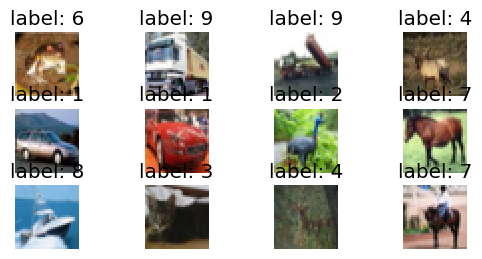

In [17]:
images_and_labels = list(zip(x_train,  y_train))
for index, (image, label) in enumerate(images_and_labels[:12]):
    plt.subplot(5, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('label: %i' % label )

In [18]:
x_train.shape

(50000, 32, 32, 3)

Сделаем предобработку данных: вытянем в один вектор и нормализуем, а также сконвертируем таргет в бинарный вид:

In [22]:
x_train = x_train.reshape(-1, 32 * 32 * 3)
x_test = x_test.reshape(-1, 32 * 32 * 3)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# конвертируем таргет в бинарный вид
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

50000 train samples
10000 test samples


In [23]:
y_train[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

Напишем функцию, которая возвращает качество у сети с заданной структурой:

In [37]:
def get_accuracy_on_deep_model(layers, data, batch_size=128, epochs=10):

    """

    Функция создает модель с несколькими скрытыми слояи (количество вершин каждого слоя
    указано в массиве layers). Каждый слой (кроме последнего, на 10 выходов)
    сопровождается Dropout с долей удаленных нейронов 0.2

    Модель обучается на данных data с гиперпараметрами batch_size и epochs.

    Для функции активации используйте relu, на последнем слое используйте softmax.

    Функция возвращает качество на тестовое выборке.

    :param layers: массив, каждый элемент равен количеству вершин на слое.
    :param data: кортеж, (x_train, y_train, x_test, y_test)
    :param batch_size: размер батча (берем по дефолту)
    :param epochs: количество эпох (берем по дефолту)
    :return: финальное качество на тестовой выборке.
    """

    x_train, y_train, x_test, y_test = data

    model = Sequential()

    # добавляем первый слой
    model.add(Dense(units=layers[0], activation='relu', input_shape = [32*32*3]))
    model.add(Dropout(0.2))

    # с помощью цикла добавляем остальные слои
    for layer in layers[1:]:
         model.add(Dense(units=layer, activation='relu'))
         model.add(Dropout(0.2))

    # добавляем последний слой
    model.add(Dense(units=10, activation='softmax'))

    # компилируем модель
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # обучаемся
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

    loss_cifar, acc_cifar = model.evaluate(x_test, y_test, verbose=0)

    # Печатаем качество на тесте:
    print(f"\nCIFAR10 Test Accuracy: {acc_cifar:.4f}")

In [38]:
data = x_train, y_train, x_test, y_test

**ПРИМЕЧАНИЕ: Во всех экспериментах далее предполагается обучение нейросети на 10 эпохах (полных проходах по обучающей выборке) с размером батча 128**

Сравним несколько архитектур с 2 скрытыми слоями:

In [39]:
get_accuracy_on_deep_model([150,512], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.2637 - loss: 1.9863 - val_accuracy: 0.3380 - val_loss: 1.8266
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.3124 - loss: 1.8690 - val_accuracy: 0.3648 - val_loss: 1.7745
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.3339 - loss: 1.8255 - val_accuracy: 0.3526 - val_loss: 1.7736
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3398 - loss: 1.8040 - val_accuracy: 0.3874 - val_loss: 1.7477
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3552 - loss: 1.7732 - val_accuracy: 0.3980 - val_loss: 1.6938
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3621 - loss: 1.7558 - val_accuracy: 0.3972 - val_loss: 1.7014
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3679 - loss: 1.7412 - val_accuracy: 0.4038 - val_loss: 1.6898
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3739 - loss: 1.7260 - 

In [40]:
get_accuracy_on_deep_model([700,150], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.2415 - loss: 2.0702 - val_accuracy: 0.3392 - val_loss: 1.8595
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.3284 - loss: 1.8545 - val_accuracy: 0.3720 - val_loss: 1.7601
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.3514 - loss: 1.7985 - val_accuracy: 0.4010 - val_loss: 1.7095
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - accuracy: 0.3704 - loss: 1.7496 - val_accuracy: 0.3984 - val_loss: 1.6897
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.3871 - loss: 1.7117 - val_accuracy: 0.4206 - val_loss: 1.6276
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.3958 - loss: 1.6858 - val_accuracy: 0.4260 - val_loss: 1.6314
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - accuracy: 0.4038 - loss: 1.6597 - val_accuracy: 0.4264 - val_loss: 1.6040
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 35s 101ms/step - accuracy: 0.4135 - loss: 1.63

In [41]:
get_accuracy_on_deep_model([150,700], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.2686 - loss: 1.9806 - val_accuracy: 0.3418 - val_loss: 1.8349
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.3157 - loss: 1.8665 - val_accuracy: 0.3598 - val_loss: 1.7901
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.3418 - loss: 1.8055 - val_accuracy: 0.3822 - val_loss: 1.7323
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.3533 - loss: 1.7746 - val_accuracy: 0.3880 - val_loss: 1.7285
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.3646 - loss: 1.7487 - val_accuracy: 0.3998 - val_loss: 1.6790
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.3725 - loss: 1.7364 - val_accuracy: 0.4142 - val_loss: 1.6642
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3779 - loss: 1.7169 - val_accuracy: 0.4112 - val_loss: 1.6543
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3834 - loss: 1.7077 - 

**Вопрос 13 (2 балла):** Какая конфигурация слоев привела к большей точности на тестовой выборке?
- A) [150,512]
- B) [700,150]
- C) [150,700]

*Ответ: B*

Теперь сравним архитектуры с 3 скрытыми слоями:

In [42]:
get_accuracy_on_deep_model([100,100,100], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.2292 - loss: 2.0600 - val_accuracy: 0.3008 - val_loss: 1.9129
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.2762 - loss: 1.9475 - val_accuracy: 0.2984 - val_loss: 1.8967
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.2876 - loss: 1.9200 - val_accuracy: 0.3290 - val_loss: 1.8380
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.2986 - loss: 1.8992 - val_accuracy: 0.3404 - val_loss: 1.8253
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3092 - loss: 1.8753 - val_accuracy: 0.3506 - val_loss: 1.8128
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.3178 - loss: 1.8637 - val_accuracy: 0.3524 - val_loss: 1.7933
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3226 - loss: 1.8536 - val_accuracy: 0.3548 - val_loss: 1.8034
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.3304 - loss: 1.8393 - va

In [43]:
get_accuracy_on_deep_model([30,150,30], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.1842 - loss: 2.1241 - val_accuracy: 0.2488 - val_loss: 1.9621
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.2228 - loss: 2.0250 - val_accuracy: 0.2714 - val_loss: 1.9306
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.2329 - loss: 1.9997 - val_accuracy: 0.2908 - val_loss: 1.9105
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.2442 - loss: 1.9842 - val_accuracy: 0.3032 - val_loss: 1.8792
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.2478 - loss: 1.9756 - val_accuracy: 0.3022 - val_loss: 1.8893
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.2506 - loss: 1.9702 - val_accuracy: 0.2758 - val_loss: 1.9127
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.2570 - loss: 1.9604 - val_accuracy: 0.2870 - val_loss: 1.9008
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.2607 - loss: 1.9517 - val_acc

In [44]:
get_accuracy_on_deep_model([250,150,75], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.2394 - loss: 2.0539 - val_accuracy: 0.3128 - val_loss: 1.8841
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.3096 - loss: 1.8879 - val_accuracy: 0.3544 - val_loss: 1.8008
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.3301 - loss: 1.8456 - val_accuracy: 0.3664 - val_loss: 1.7551
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.3418 - loss: 1.8138 - val_accuracy: 0.3678 - val_loss: 1.7525
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.3516 - loss: 1.7884 - val_accuracy: 0.3944 - val_loss: 1.7034
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.3630 - loss: 1.7613 - val_accuracy: 0.4106 - val_loss: 1.6671
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.3696 - loss: 1.7408 - val_accuracy: 0.4008 - val_loss: 1.6727
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.3746 - loss: 1.7239 - 

In [45]:
get_accuracy_on_deep_model([750,250,75], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.2256 - loss: 2.0878 - val_accuracy: 0.2924 - val_loss: 1.9113
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.3153 - loss: 1.8834 - val_accuracy: 0.3502 - val_loss: 1.8209
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 46s 130ms/step - accuracy: 0.3429 - loss: 1.8174 - val_accuracy: 0.3900 - val_loss: 1.7248
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.3572 - loss: 1.7775 - val_accuracy: 0.3988 - val_loss: 1.6940
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.3678 - loss: 1.7383 - val_accuracy: 0.4060 - val_loss: 1.6604
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.3828 - loss: 1.7151 - val_accuracy: 0.4126 - val_loss: 1.6392
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.3879 - loss: 1.6937 - val_accuracy: 0.4250 - val_loss: 1.6256
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.3939 - loss: 1.6

**Вопрос 14 (2 балла):** Какая конфигурация слоев привела к большей точности на тестовой выборке?
- A) [100,100,100]
- B) [30,150,30]
- C) [250,150,75]

*Ответ: C*

И, наконец, посмотрим на архитектуры с 4 скрытыми слоями:

In [46]:
get_accuracy_on_deep_model([150,20,150,20], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.1782 - loss: 2.1521 - val_accuracy: 0.2320 - val_loss: 2.0157
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.2330 - loss: 2.0203 - val_accuracy: 0.2862 - val_loss: 1.9263
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.2562 - loss: 1.9641 - val_accuracy: 0.3114 - val_loss: 1.8734
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.2755 - loss: 1.9289 - val_accuracy: 0.3388 - val_loss: 1.8396
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.2846 - loss: 1.9134 - val_accuracy: 0.3366 - val_loss: 1.8336
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.2977 - loss: 1.8894 - val_accuracy: 0.3198 - val_loss: 1.8407
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.3036 - loss: 1.8747 - val_accuracy: 0.3492 - val_loss: 1.7960
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.3141 - loss: 1.8634 - 

In [47]:
get_accuracy_on_deep_model([120,40,120,40], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.1875 - loss: 2.1391 - val_accuracy: 0.2830 - val_loss: 1.9383
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.2624 - loss: 1.9793 - val_accuracy: 0.3302 - val_loss: 1.8825
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.2846 - loss: 1.9291 - val_accuracy: 0.3302 - val_loss: 1.8607
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.2961 - loss: 1.9063 - val_accuracy: 0.3524 - val_loss: 1.8215
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.3055 - loss: 1.8950 - val_accuracy: 0.3446 - val_loss: 1.8407
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.3134 - loss: 1.8796 - val_accuracy: 0.3634 - val_loss: 1.7957
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.3154 - loss: 1.8677 - val_accuracy: 0.3662 - val_loss: 1.8037
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.3202 - loss: 1.8606 - 

In [48]:
get_accuracy_on_deep_model([155,5,155,5], data)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.0969 - loss: 2.3028 - val_accuracy: 0.0958 - val_loss: 2.3028
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.0991 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3028
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.0989 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3028
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.0998 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3027
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.0976 - loss: 2.3027 - val_accuracy: 0.0958 - val_loss: 2.3028
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.0983 - loss: 2.3027 - val_accuracy: 0.0970 - val_loss: 2.3029
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.0966 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3029
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.1009 - loss: 2.3027 - 

**Вопрос 15 (2 балла):** Какая конфигурация слоев привела к большей точности на тестовой выборке?
- A) [150,20,150,20]
- B) [120,40,120,40]
- С) [155,5,155,5]

*Ответ: A*

**Вопрос 16 (1 балл):** Почему полносвязная нейросеть показывает на CIFAR10 значительно более низкую точность на тестовой выборке, чем на MNIST?
- A) В CIFAR10 меньше обучающих примеров, чем в MNIST.
- B) Использовался слишком большая learning rate.
- C) CIFAR10 это цветные изображения с более сложной семантикой (собаки, корабли и т.д.), и при вытягивании картинки в вектор теряется пространственная информация, что делает полносвязные сети неэффективными для таких данных.
- D) В CIFAR10 больше классов, чем в MNIST.

*Ответ: C*